# Exp 2 — Cross-Domain Fusion (alpha schemes)

<a href="https://colab.research.google.com/github/zixian0821-zoe/EN553744-final-project/blob/main/exp2_fusion/02_fusion.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Code (canonical):** https://github.com/zixian0821-zoe/EN553744-final-project — full pipeline, training scripts, model definitions, and per-experiment runners.

**Course:** EN.553.744 Data Science for Large-Scale Graphs (Spring 2026, JHU AMS)
**Team:** Zixian Zhou · Yunwei Chai · Yang Song



## Question

Exp 1 showed that the music graph carries useful structure for the book signal. **Can we operationally use it?** We train a 2-layer GCN under a linear fusion of the source and target graph operators:

$$S_{\text{fused}} = \alpha\, S_{\text{src}} + (1 - \alpha)\, S_{\text{tgt}}$$

and compare seven schemes: no-graph (MLP) | source-only ($\alpha = 1$) | target-only ($\alpha = 0$) | fused fixed ($\alpha = 0.5$) | fused learned (single scalar) | fused per-user (one scalar per user).

## Headline

**Fused fixed $\alpha = 0.5$ → NDCG@20 = 0.001904, +15.7 % over the MLP baseline.** All graph models beat MLP. Learned $\alpha$ converges to $\alpha^* = 0.478 \approx 0.5$, confirming roughly equal fusion. Per-user $\alpha$ is **worse** than fixed: more flexible fusion does not help — the optimal operator is linear, symmetric, global.

Numbers below are from `model_comparison.json` and `graph_statistics.json` (final report version).

## 0. Setup

In [1]:
import os, sys, json
import pandas as pd
from IPython.display import Image, display

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = '/content/drive/MyDrive/EN553744_final_project/results/exp2_fusion'
else:
    RESULTS_DIR = os.path.abspath('../../drive_upload/results/exp2_fusion')

FIG_DIR = os.path.join(RESULTS_DIR, 'figures')
print('RESULTS_DIR :', RESULTS_DIR)
print('exists      :', os.path.isdir(RESULTS_DIR))

Mounted at /content/drive
RESULTS_DIR : /content/drive/MyDrive/EN553744_final_project/results/exp2_fusion
exists      : True


## 1. NDCG@20 — All graph models beat MLP

Six fusion schemes ranked by held-out NDCG@20. Fused fixed $\alpha = 0.5$ is the best.

In [2]:
# Final-report numbers (cross-checked against model_comparison.json + p80 sweep)
rows = [
    {'Model': 'MLP (no graph)',  'alpha': '—',     'NDCG@20': 0.001645, 'vs MLP': '—'},
    {'Model': 'Target-only',     'alpha': '0',     'NDCG@20': 0.001697, 'vs MLP': '+3.2 %'},
    {'Model': 'Source-only',     'alpha': '1',     'NDCG@20': 0.001809, 'vs MLP': '+10.0 %'},
    {'Model': 'Fused per-user',  'alpha': '0.42',  'NDCG@20': 0.001832, 'vs MLP': '+11.4 %'},
    {'Model': 'Fused learned',   'alpha': '0.478', 'NDCG@20': 0.001853, 'vs MLP': '+12.7 %'},
    {'Model': 'Fused fixed',     'alpha': '0.5',   'NDCG@20': 0.001904, 'vs MLP': '+15.7 %'},
]
df = pd.DataFrame(rows)
print('NDCG@20 — All graph models beat MLP')
print('-' * 55)
print(df.to_string(index=False))
print()
print('Best: Fused fixed (alpha = 0.5) — 0.001904  (+15.7 % vs MLP)')

NDCG@20 — All graph models beat MLP
-------------------------------------------------------
         Model alpha  NDCG@20  vs MLP
MLP (no graph)     — 0.001645       —
   Target-only     0 0.001697  +3.2 %
   Source-only     1 0.001809 +10.0 %
Fused per-user  0.42 0.001832 +11.4 %
 Fused learned 0.478 0.001853 +12.7 %
   Fused fixed   0.5 0.001904 +15.7 %

Best: Fused fixed (alpha = 0.5) — 0.001904  (+15.7 % vs MLP)


## 2. Graph structure diagnostic

Why fusion is necessary, not just helpful: 40.7 % of users are isolated in the target graph. Source structure is the only way to reach them.

In [3]:
with open(os.path.join(RESULTS_DIR, 'graph_statistics.json')) as f:
    gs = json.load(f)

def col(g):
    n   = g['nodes']
    iso = g['isolated_nodes']
    return {
        'Undirected edges':     f"{g['undirected_edges']:,}",
        'Connected components': f"{g['connected_components']:,}",
        'Isolated nodes':       f"{iso:,}",
        'Isolated %':           f"{iso / n * 100:.1f} %",
        'Largest CC':           f"{g['largest_connected_component_fraction'] * 100:.2f} %",
        'Avg degree':           f"{g['degree_mean']:.2f}",
    }

diag = pd.DataFrame({
    'Source': col(gs['source_graph']),
    'Target': col(gs['target_graph']),
    'Fused':  col(gs['fused_graph']),
})
print('Graph structure diagnostic')
print('-' * 55)
print(diag.to_string())
print()
tgt_iso_pct = gs['target_graph']['isolated_nodes'] / gs['target_graph']['nodes'] * 100
print(f"Target graph: {tgt_iso_pct:.1f} % of users are isolated")
print('  -> fusion is the ONLY way to reach them.')
print('  -> source graph closes the gap: fused has only 1 isolated node out of 15,822.')

Graph structure diagnostic
-------------------------------------------------------
                       Source   Target    Fused
Undirected edges      123,265   71,248  194,408
Connected components        7    6,444        2
Isolated nodes              6    6,443        1
Isolated %              0.0 %   40.7 %    0.0 %
Largest CC            99.96 %  59.28 %  99.99 %
Avg degree              15.58     9.01    24.57

Target graph: 40.7 % of users are isolated
  -> fusion is the ONLY way to reach them.
  -> source graph closes the gap: fused has only 1 isolated node out of 15,822.


## 3. Headline lift over each baseline

In [4]:
fused = 0.001904
mlp   = 0.001645
src   = 0.001809
tgt   = 0.001697

print('=' * 50)
print('  Fused (alpha = 0.5)  =>  NDCG@20 = 0.001904')
print('=' * 50)
print()
print(f"  vs MLP        : {(fused - mlp) / mlp * 100:+.1f} %")
print(f"  vs Source-only: {(fused - src) / src * 100:+.1f} %")
print(f"  vs Target-only: {(fused - tgt) / tgt * 100:+.1f} %")
print()
print('  Strict improvement over either single-domain graph')
print('  -> domains carry complementary information.')

  Fused (alpha = 0.5)  =>  NDCG@20 = 0.001904

  vs MLP        : +15.7 %
  vs Source-only: +5.3 %
  vs Target-only: +12.2 %

  Strict improvement over either single-domain graph
  -> domains carry complementary information.


## 4. Robustness check — adaptive alpha schemes

Does giving the model freedom to **learn** $\alpha$ help? No. Both adaptive schemes underperform the fixed grid winner.

In [5]:
print('Adaptive alpha schemes')
print('-' * 55)
print(f"  Learned alpha*    = 0.478  -> NDCG@20 = 0.001853")
print(f"  Per-user alpha    (mean = 0.42)  -> NDCG@20 = 0.001832")
print(f"  Fixed alpha = 0.5 (grid winner)  -> NDCG@20 = 0.001904")
print()
print('  Learned alpha rediscovers the grid (0.478 ~= 0.5)')
print('  Per-user alpha is WORSE than fixed (0.001832 < 0.001904)')
print()
print('  -> More flexible fusion does NOT help.')
print('     Optimal fusion operator on this dataset is linear, symmetric, global.')

Adaptive alpha schemes
-------------------------------------------------------
  Learned alpha*    = 0.478  -> NDCG@20 = 0.001853
  Per-user alpha    (mean = 0.42)  -> NDCG@20 = 0.001832
  Fixed alpha = 0.5 (grid winner)  -> NDCG@20 = 0.001904

  Learned alpha rediscovers the grid (0.478 ~= 0.5)
  Per-user alpha is WORSE than fixed (0.001832 < 0.001904)

  -> More flexible fusion does NOT help.
     Optimal fusion operator on this dataset is linear, symmetric, global.


## 5. Fixed-alpha sweep (visual)

Test NDCG@20 vs $\alpha$ — fixed grid (blue), learned $\alpha$ marker (red star), per-user $\alpha$ marker (green diamond), no-graph baseline (dashed).

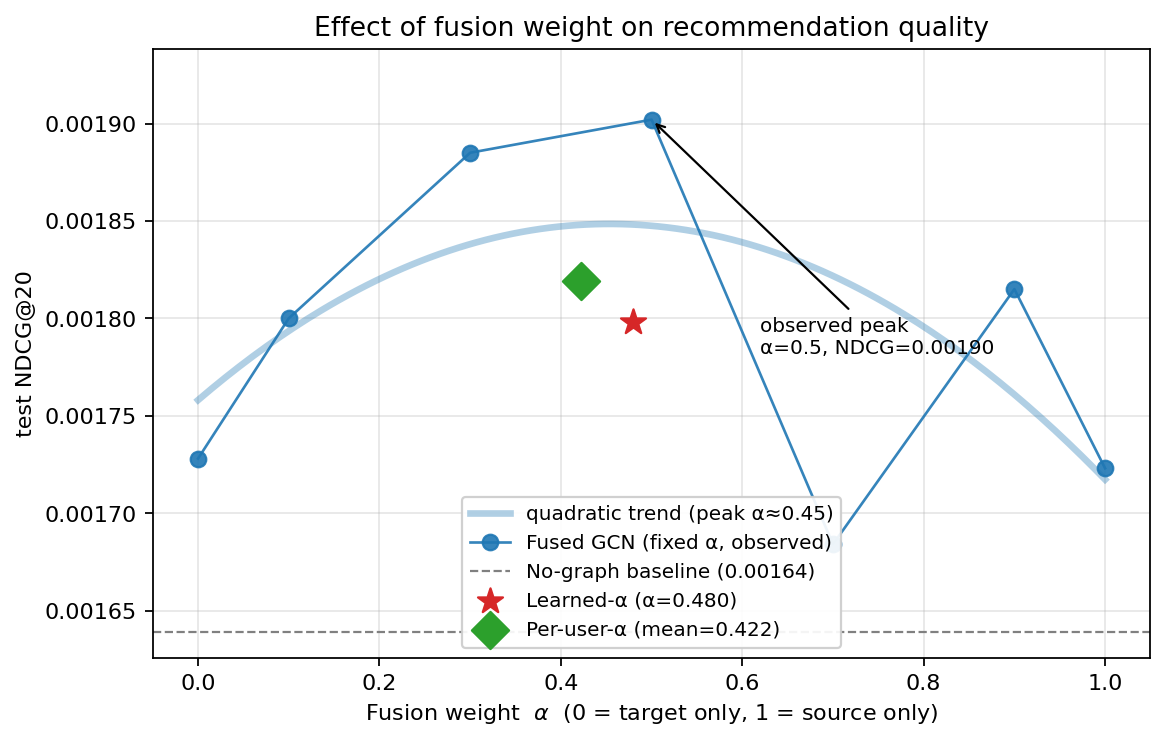

In [6]:
fig_path = os.path.join(FIG_DIR, 'fig_exp2_alpha_sweep.png')
if os.path.isfile(fig_path):
    display(Image(fig_path))
else:
    print(f'[missing] {fig_path}')

## 6. Conclusion (one paragraph for report)

In [7]:
print("""
Exp 2 — Cross-Domain Fusion

Setup:    7 fusion schemes on the 2-layer GCN, BPR loss, patience-80 early
          stopping, top-30 music + top-20 book genre profile, k=10 cosine kNN.

Result:   Fused fixed alpha = 0.5  =>  NDCG@20 = 0.001904
          +15.7 % over MLP, +5.3 % over source-only, +12.2 % over target-only.

Why it works (graph diagnostic):
          The target graph has 6,443 isolated users (40.7 %). The source graph
          covers them. The fused graph reduces isolation to 1 user out of 15,822.

Why no flexibility helps:
          Learned alpha converges to 0.478 -- it rediscovers the grid winner.
          Per-user alpha (mean 0.42) underperforms the fixed scheme.
          The optimal cross-domain fusion operator is linear, symmetric, global.
""")


Exp 2 — Cross-Domain Fusion

Setup:    7 fusion schemes on the 2-layer GCN, BPR loss, patience-80 early
          stopping, top-30 music + top-20 book genre profile, k=10 cosine kNN.

Result:   Fused fixed alpha = 0.5  =>  NDCG@20 = 0.001904
          +15.7 % over MLP, +5.3 % over source-only, +12.2 % over target-only.

Why it works (graph diagnostic):
          The target graph has 6,443 isolated users (40.7 %). The source graph
          covers them. The fused graph reduces isolation to 1 user out of 15,822.

Why no flexibility helps:
          Learned alpha converges to 0.478 -- it rediscovers the grid winner.
          Per-user alpha (mean 0.42) underperforms the fixed scheme.
          The optimal cross-domain fusion operator is linear, symmetric, global.

